# MATH 210 Introduction to Mathematical Computing

**March 6, 2026**

* Examples
* `scipy.integrate`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

## Examples

Approximate the integral $\int_0^1 e^{\cos(\pi x)} dx$ using each of our methods for $N=1000$ and find a bound for the error.

Compute derivatives of $f(x) = e^{\cos(\pi x)}$:

$$
f'(x) = -\pi \sin(\pi x) e^{\cos(\pi x)} \hspace{10mm}
f''(x) = -\pi^2 \cos(\pi x) e^{\cos(\pi x)} + \pi^2 \sin^2(\pi x) e^{\cos(\pi x)}
$$

In [4]:
K1 = np.e*np.pi
K2 = 2*np.e*np.pi**2

In [5]:
print(K1,K2)

8.539734222673566 53.656732595121234


Plot the graphs:

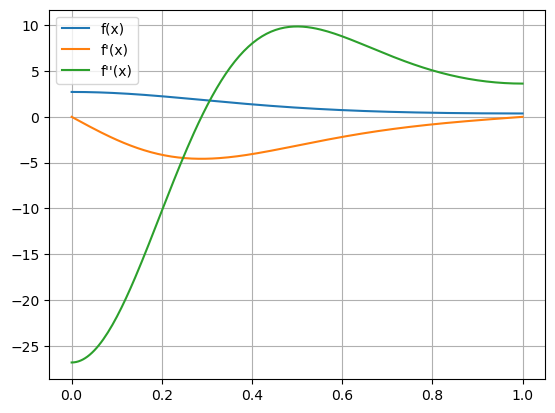

In [6]:
x = np.linspace(0,1,200)
f = lambda x: np.exp(np.cos(np.pi*x))
df = lambda x: -np.pi*np.sin(np.pi*x)*np.exp(np.cos(np.pi*x))
ddf = lambda x: -np.pi**2*np.cos(np.pi*x)*np.exp(np.cos(np.pi*x)) + np.pi**2*np.sin(np.pi*x)**2*np.exp(np.cos(np.pi*x))
plt.plot(x,f(x),x,df(x),x,ddf(x))
plt.legend(["f(x)","f'(x)","f''(x)"]), plt.grid(True)
plt.show()

In [7]:
K1 = np.max(np.abs(df(x)))
print(K1)

4.581988928046055


In [8]:
K2 = np.abs(ddf(0))
print(K2)

26.828366297560617


In [9]:
a = 0; b = 1; N = 1000; dx = (b - a)/N;
x = np.linspace(a,b,N+1)
y = f(x)

R = dx*np.sum(y[1:])
ER = (b - a)**2*K1/2/N
print("Right Riemann Sum:",R,"+-",ER)

L = dx*np.sum(y[:-1])
EL = (b - a)**2*K1/2/N
print("Left Riemann Sum:",L,"+-",EL)

mids = (x[:-1] + x[1:])/2 # x[:-1] + dx/2
ymids = f(mids)
M = dx*np.sum(ymids)
EM = (b - a)**3*K2/24/N**2
print("Midpoint Riemann Sum:",M,"+-",EM)

T = spi.trapezoid(f(x),x) # (R + L)/2
ET = (b - a)**3*K2/12/N**2
print("Trapezoid Rule:",T,"+-",ET)

S = spi.simpson(f(x),x)
print("Simpson's Rule:",S)

Right Riemann Sum: 1.2648906765583647 +- 0.0022909944640230277
Left Riemann Sum: 1.267241078945652 +- 0.0022909944640230277
Midpoint Riemann Sum: 1.2660658777520084 +- 1.1178485957316924e-06
Trapezoid Rule: 1.2660658777520084 +- 2.2356971914633847e-06
Simpson's Rule: 1.2660658777520082


In [10]:
f = lambda x: np.exp(np.cos(np.pi*x))
a = 0; b = 1;
I,E = spi.quad(f,a,b)
print(I,"+-",E)

1.2660658777520084 +- 3.877952221772689e-12
